Import Required Libraries

In [1]:
from pathlib import Path
import random

import cv2
import yaml
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

print("✓ Libraries imported successfully.")

✓ Libraries imported successfully.


Dataset Path Configuration

In [2]:
from pathlib import Path

PROJECT_PATH = Path(r"E:\ML_Project")

DATASET_PATH = PROJECT_PATH / "datasets" / "bdd100k_original_yolo"

train_images = DATASET_PATH / "train" / "images"
train_labels = DATASET_PATH / "train" / "labels"

valid_images = DATASET_PATH / "valid" / "images"
valid_labels = DATASET_PATH / "valid" / "labels"

test_images = DATASET_PATH / "test" / "images"
test_labels = DATASET_PATH / "test" / "labels"

data_yaml = DATASET_PATH / "bdd100k.yaml"

print("✓ Dataset paths configured successfully.")

✓ Dataset paths configured successfully.


Load Dataset Configuration

In [3]:
with open(data_yaml, "r") as f:
    data_config = yaml.safe_load(f)

print("✓ Dataset configuration loaded successfully.")

✓ Dataset configuration loaded successfully.


Dataset Overview

In [4]:
train_count = len(list(train_images.glob("*.jpg")))
valid_count = len(list(valid_images.glob("*.jpg")))
test_count = len(list(test_images.glob("*.jpg")))

print("=" * 60)
print("Dataset Overview")
print("=" * 60)

print(f"Training Images    : {train_count:,}")
print(f"Validation Images  : {valid_count:,}")
print(f"Testing Images     : {test_count:,}")

print("-" * 60)

print(f"Total Images       : {train_count + valid_count + test_count:,}")

print()

class_names = data_config["names"]

if isinstance(class_names, dict):
    class_names = [
        class_names[i]
        for i in range(len(class_names))
    ]

print(f"Number of Classes  : {len(class_names)}")

print()

print("Class Names")

for idx, name in enumerate(class_names):
    print(f"{idx:2d} : {name}")

Dataset Overview
Training Images    : 70,000
Validation Images  : 10,000
Testing Images     : 20,000
------------------------------------------------------------
Total Images       : 100,000

Number of Classes  : 10

Class Names
 0 : bike
 1 : bus
 2 : car
 3 : motor
 4 : person
 5 : rider
 6 : traffic light
 7 : traffic sign
 8 : train
 9 : truck


Random Image Visualization

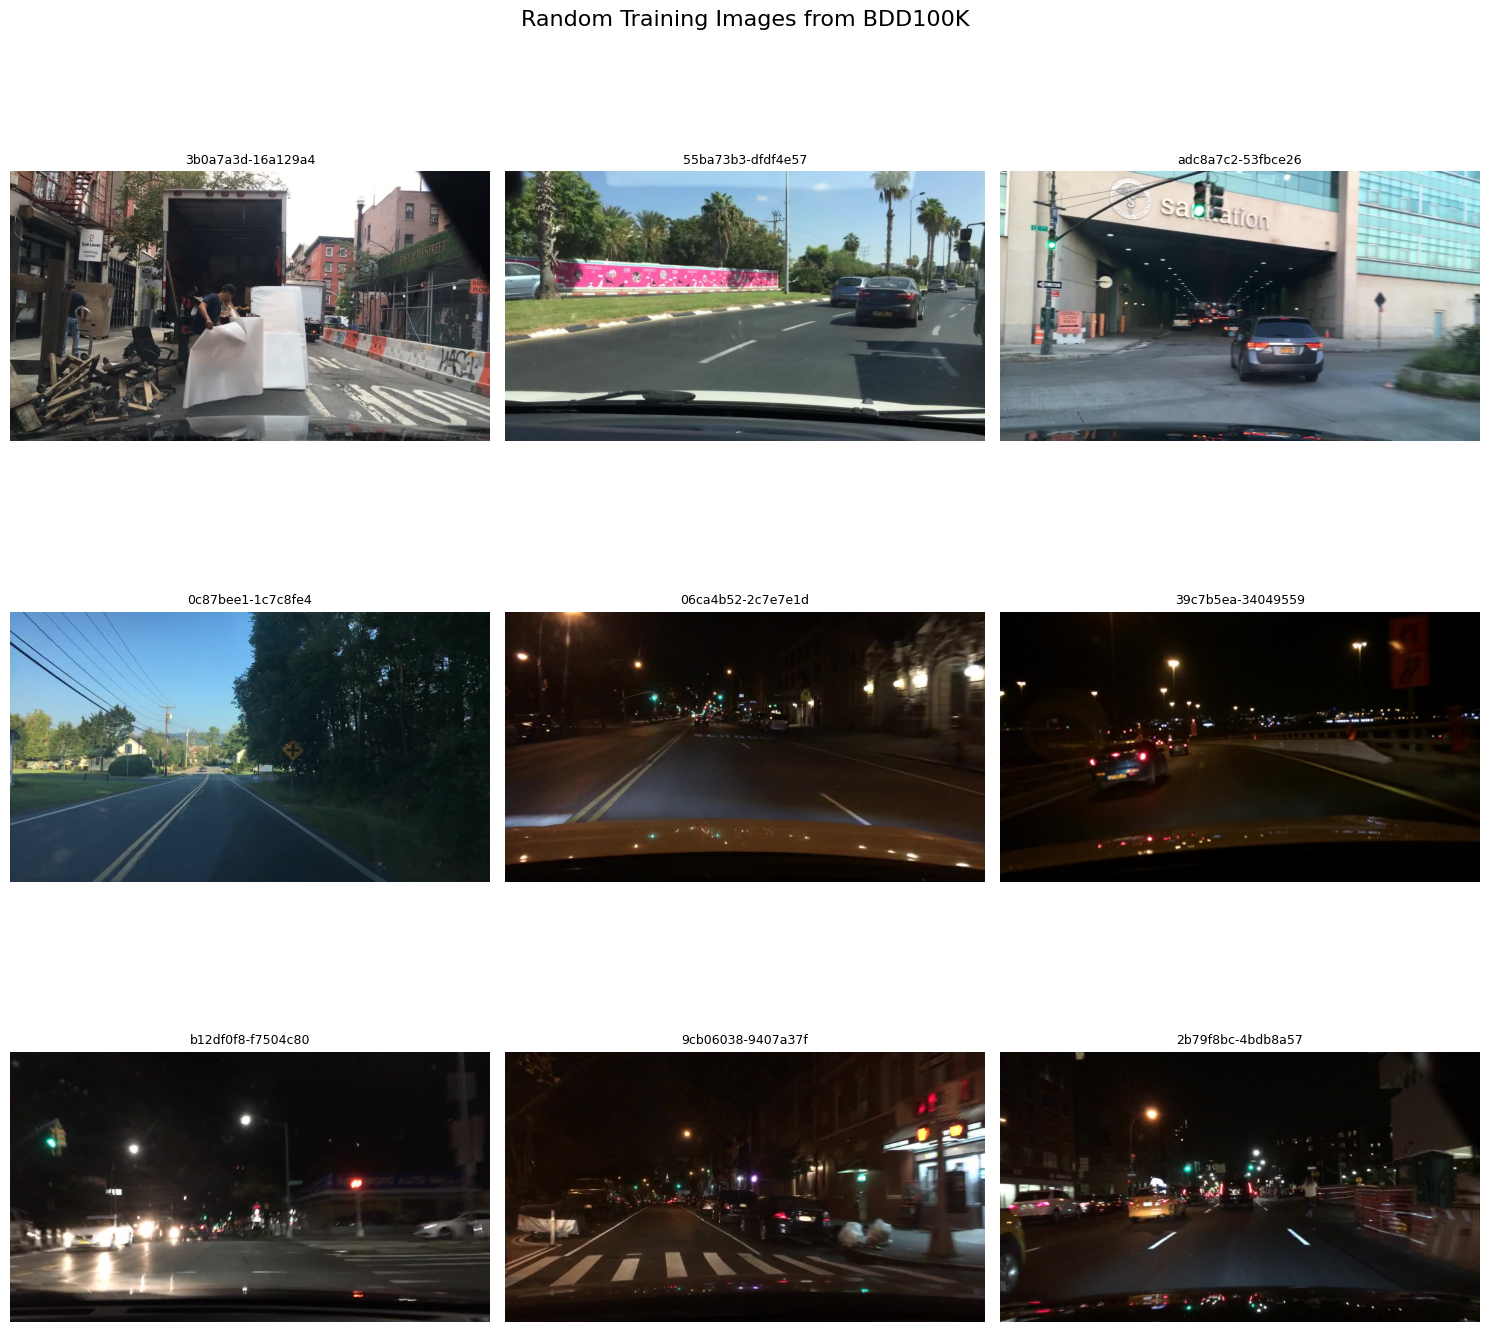

In [5]:
sample_images = random.sample(list(train_images.glob("*.jpg")), 9)

fig, axes = plt.subplots(3, 3, figsize=(15, 15))

for ax, image_path in zip(axes.ravel(), sample_images):

    image = cv2.imread(str(image_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    ax.imshow(image)
    ax.set_title(image_path.stem, fontsize=9)
    ax.axis("off")

plt.suptitle(
    "Random Training Images from BDD100K",
    fontsize=16
)

plt.tight_layout()

figure_folder = PROJECT_PATH / "figures"
figure_folder.mkdir(exist_ok=True)

plt.savefig(
    figure_folder / "random_training_images.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Sample Images with Bounding Boxes

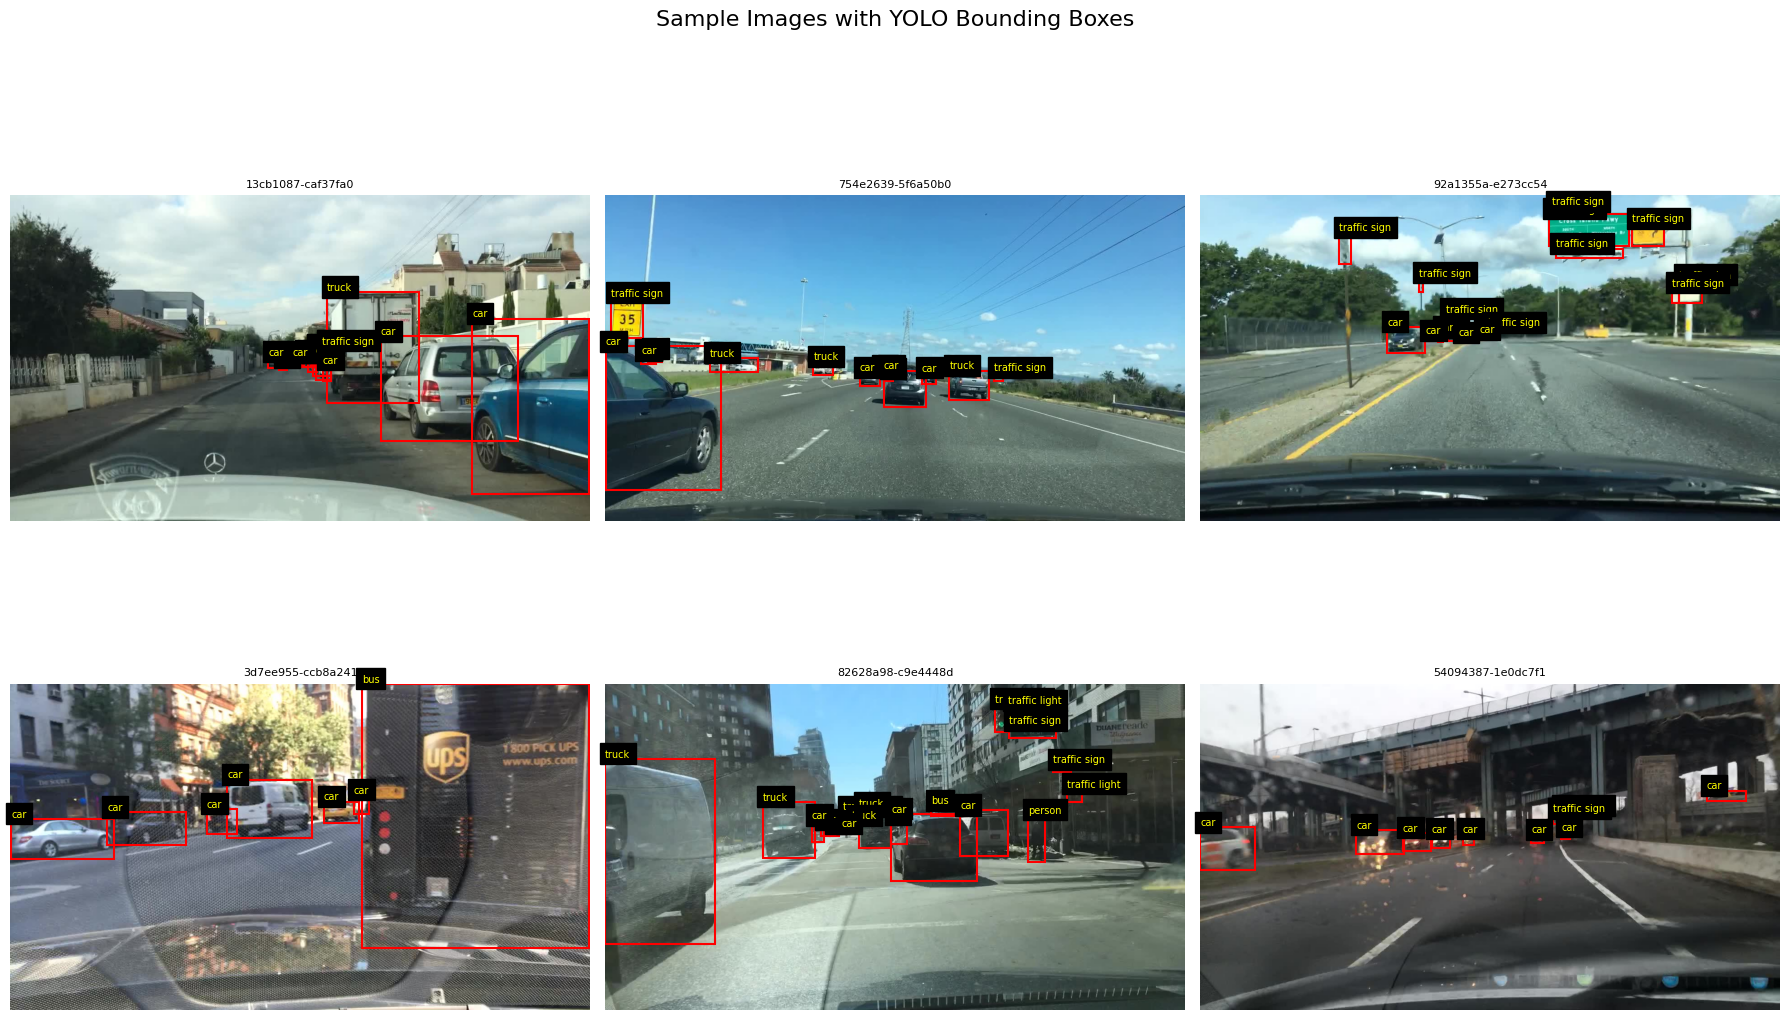

✓ Figure saved successfully.


In [6]:
sample_images = random.sample(
    list(train_images.glob("*.jpg")),
    6
)
fig, axes = plt.subplots(
    2, 3,
    figsize=(18, 12)
)

# Prepare class names
names = data_config["names"]
if isinstance(names, dict):
    class_names = [
        names[i]
        for i in range(len(names))
    ]
else:
    class_names = list(names)


for ax, image_path in zip(axes.ravel(), sample_images):

    image = cv2.imread(str(image_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    h, w = image.shape[:2]

    label_path = train_labels / f"{image_path.stem}.txt"

    if label_path.exists():

        with open(label_path, "r") as f:

            for line in f:

                values = line.strip().split()

                if len(values) != 5:
                    continue

                class_id = int(values[0])

                x_center = float(values[1]) * w
                y_center = float(values[2]) * h
                box_width = float(values[3]) * w
                box_height = float(values[4]) * h

                x = x_center - box_width / 2
                y = y_center - box_height / 2

                rect = Rectangle(
                    (x, y),
                    box_width,
                    box_height,
                    linewidth=1.5,
                    edgecolor="red",
                    facecolor="none"
                )

                ax.add_patch(rect)

                ax.text(
                    x,
                    y - 5,
                    class_names[class_id],
                    color="yellow",
                    fontsize=7,
                    backgroundcolor="black"
                )

    ax.imshow(image)
    ax.set_title(
        image_path.stem,
        fontsize=8
    )
    ax.axis("off")


plt.suptitle(
    "Sample Images with YOLO Bounding Boxes",
    fontsize=16
)

plt.tight_layout()

figure_folder = PROJECT_PATH / "figures"
figure_folder.mkdir(exist_ok=True)

plt.savefig(
    figure_folder / "sample_bounding_boxes.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✓ Figure saved successfully.")

Image Resolution Analysis

In [7]:
from collections import Counter
resolution_counter = Counter()

for image_path in train_images.glob("*.jpg"):
    image = cv2.imread(str(image_path))
    h, w = image.shape[:2]

    resolution_counter[(w, h)] += 1

print("=" * 60)
print("Image Resolution Statistics")
print("=" * 60)

for resolution, count in resolution_counter.items():
    print(f"{resolution[0]} × {resolution[1]} : {count:,}")

Image Resolution Statistics
1280 × 720 : 70,000


Enhanced Scene Complexity Analysis

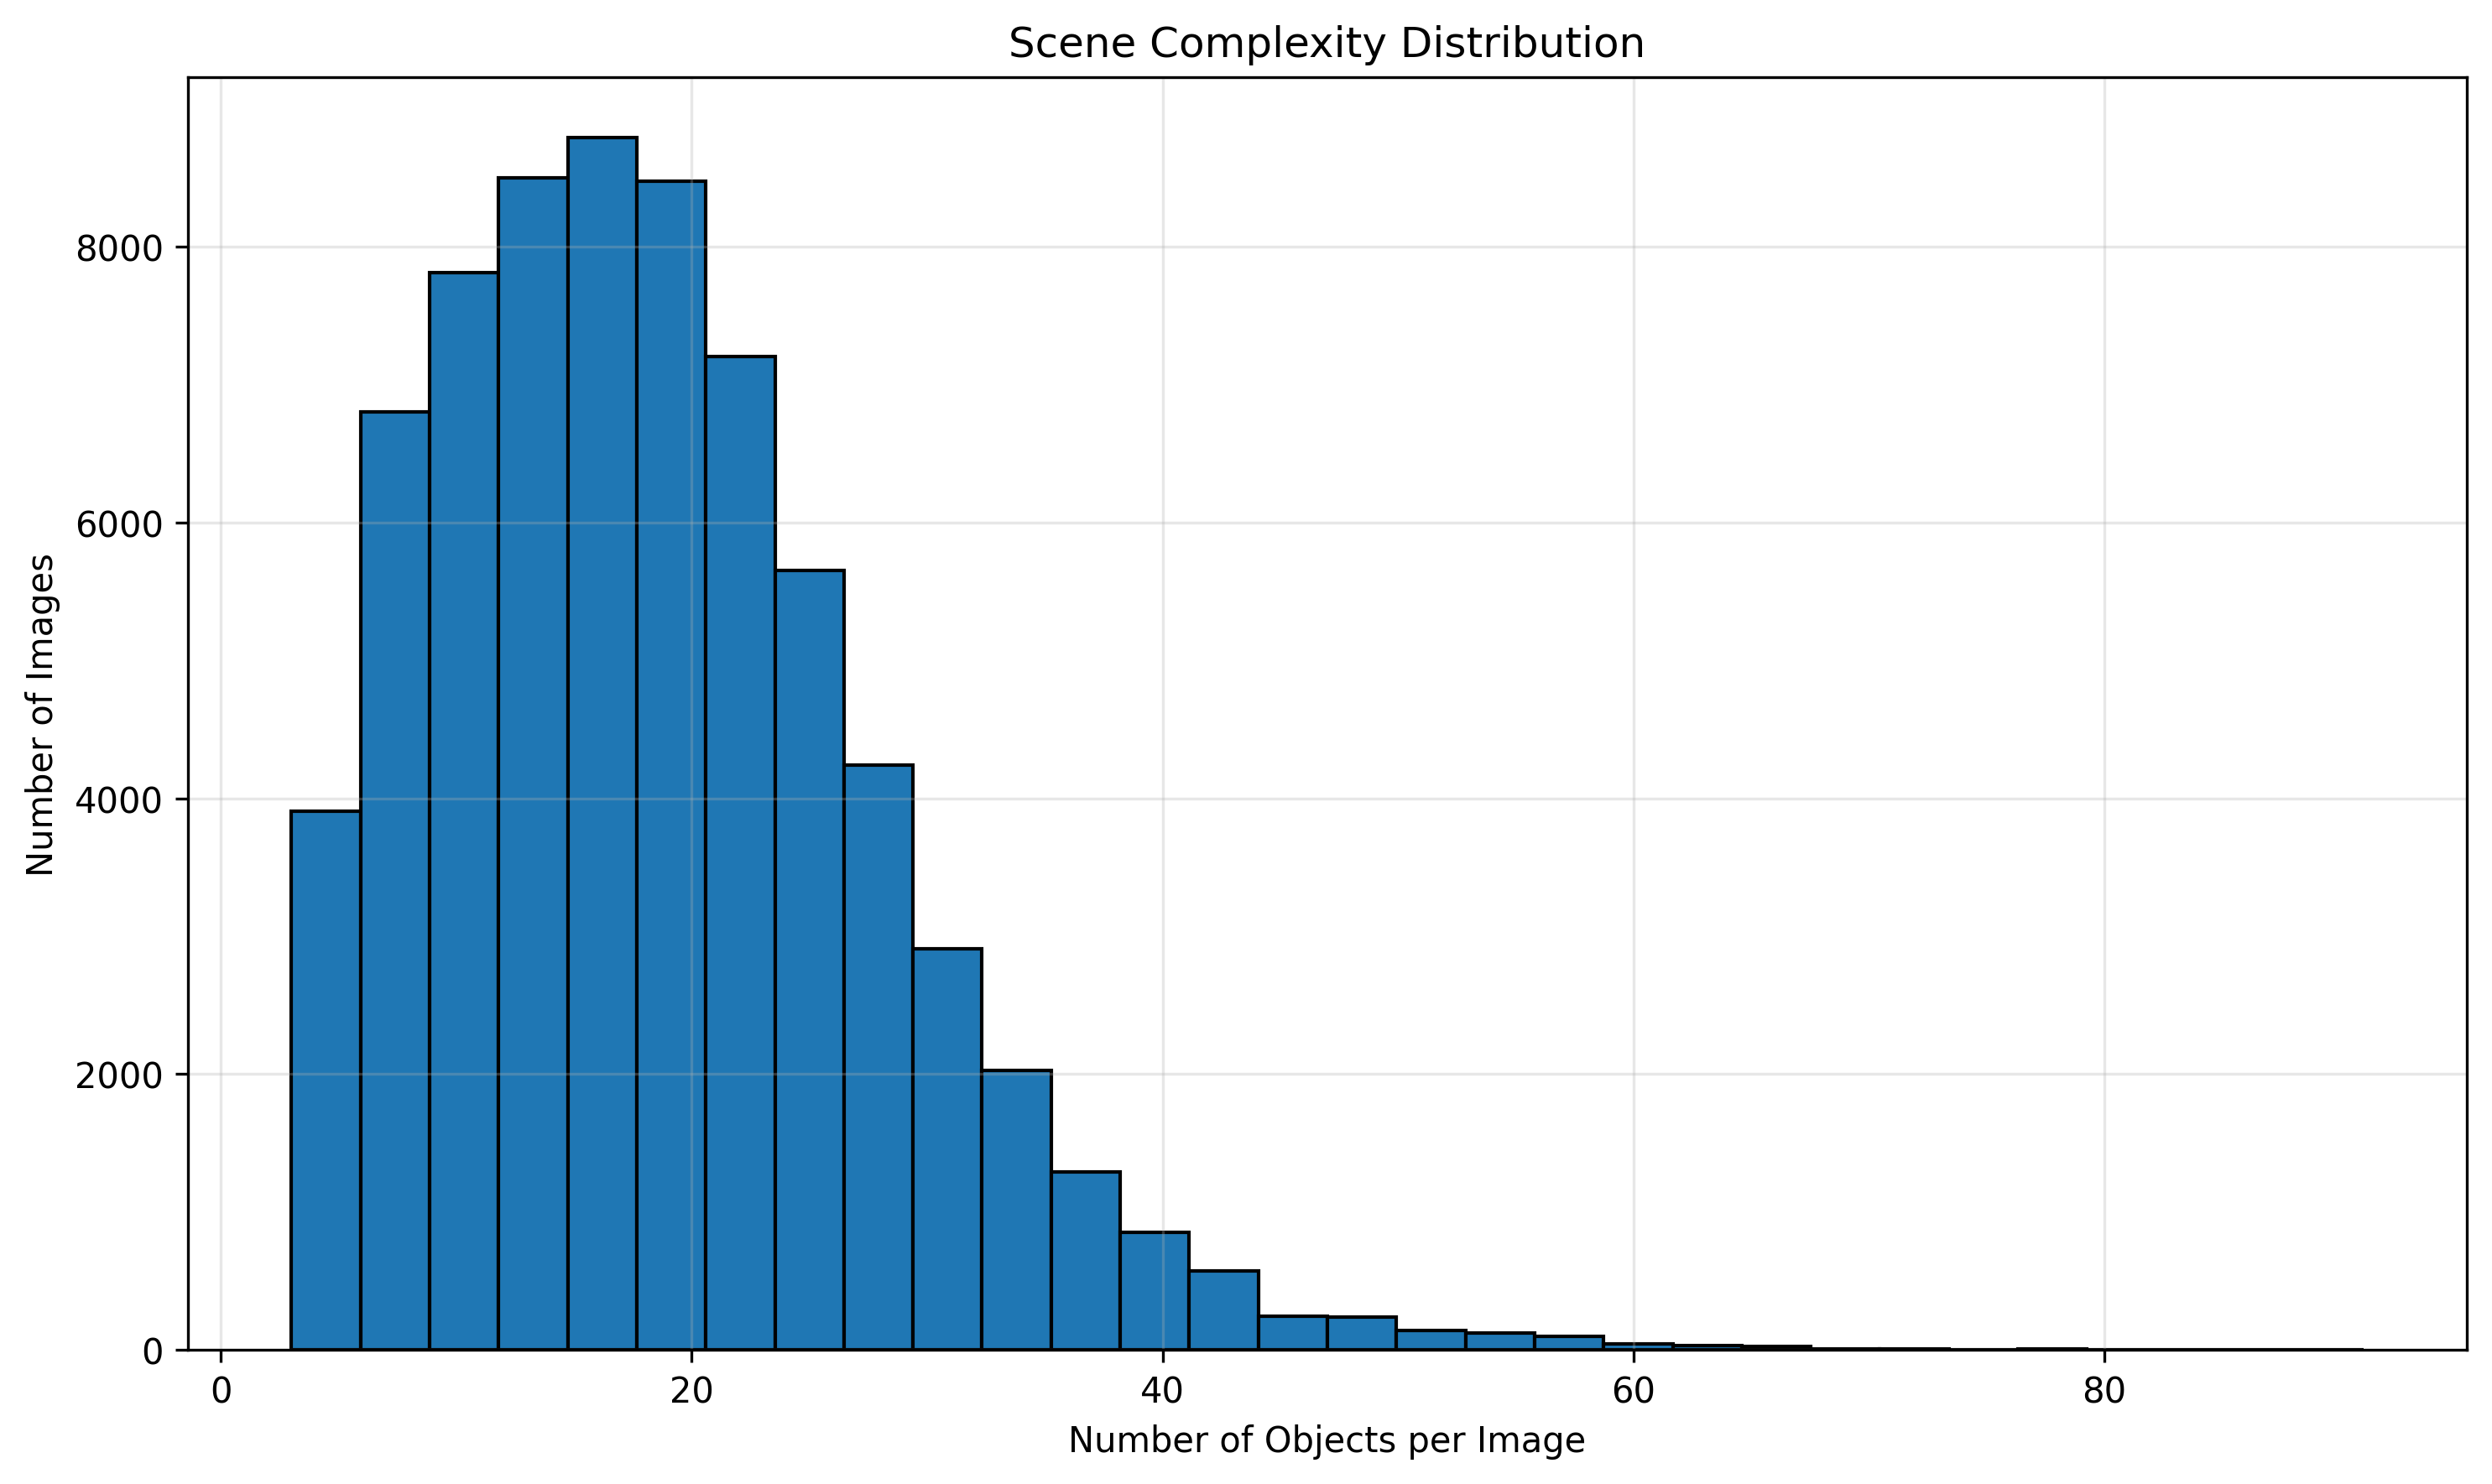

Scene Complexity Statistics
Mean      : 18.40
Median    : 17.00
Std Dev   : 9.62
Minimum   : 3
Maximum   : 91
25%       : 11.00
75%       : 24.00


In [8]:
objects_per_image = []

for label_file in train_labels.glob("*.txt"):

    with open(label_file, "r") as f:
        count = sum(1 for line in f if line.strip())

    objects_per_image.append(count)

objects_per_image = np.array(objects_per_image)

plt.figure(figsize=(10,6), dpi=300)
plt.hist(objects_per_image,
         bins=30,
         edgecolor="black")
plt.title("Scene Complexity Distribution")
plt.xlabel("Number of Objects per Image")
plt.ylabel("Number of Images")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(
    figure_folder / "scene_complexity_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print("="*60)
print("Scene Complexity Statistics")
print("="*60)
print(f"Mean      : {objects_per_image.mean():.2f}")
print(f"Median    : {np.median(objects_per_image):.2f}")
print(f"Std Dev   : {objects_per_image.std():.2f}")
print(f"Minimum   : {objects_per_image.min()}")
print(f"Maximum   : {objects_per_image.max()}")
print(f"25%       : {np.percentile(objects_per_image,25):.2f}")
print(f"75%       : {np.percentile(objects_per_image,75):.2f}")

Object Size Analysis

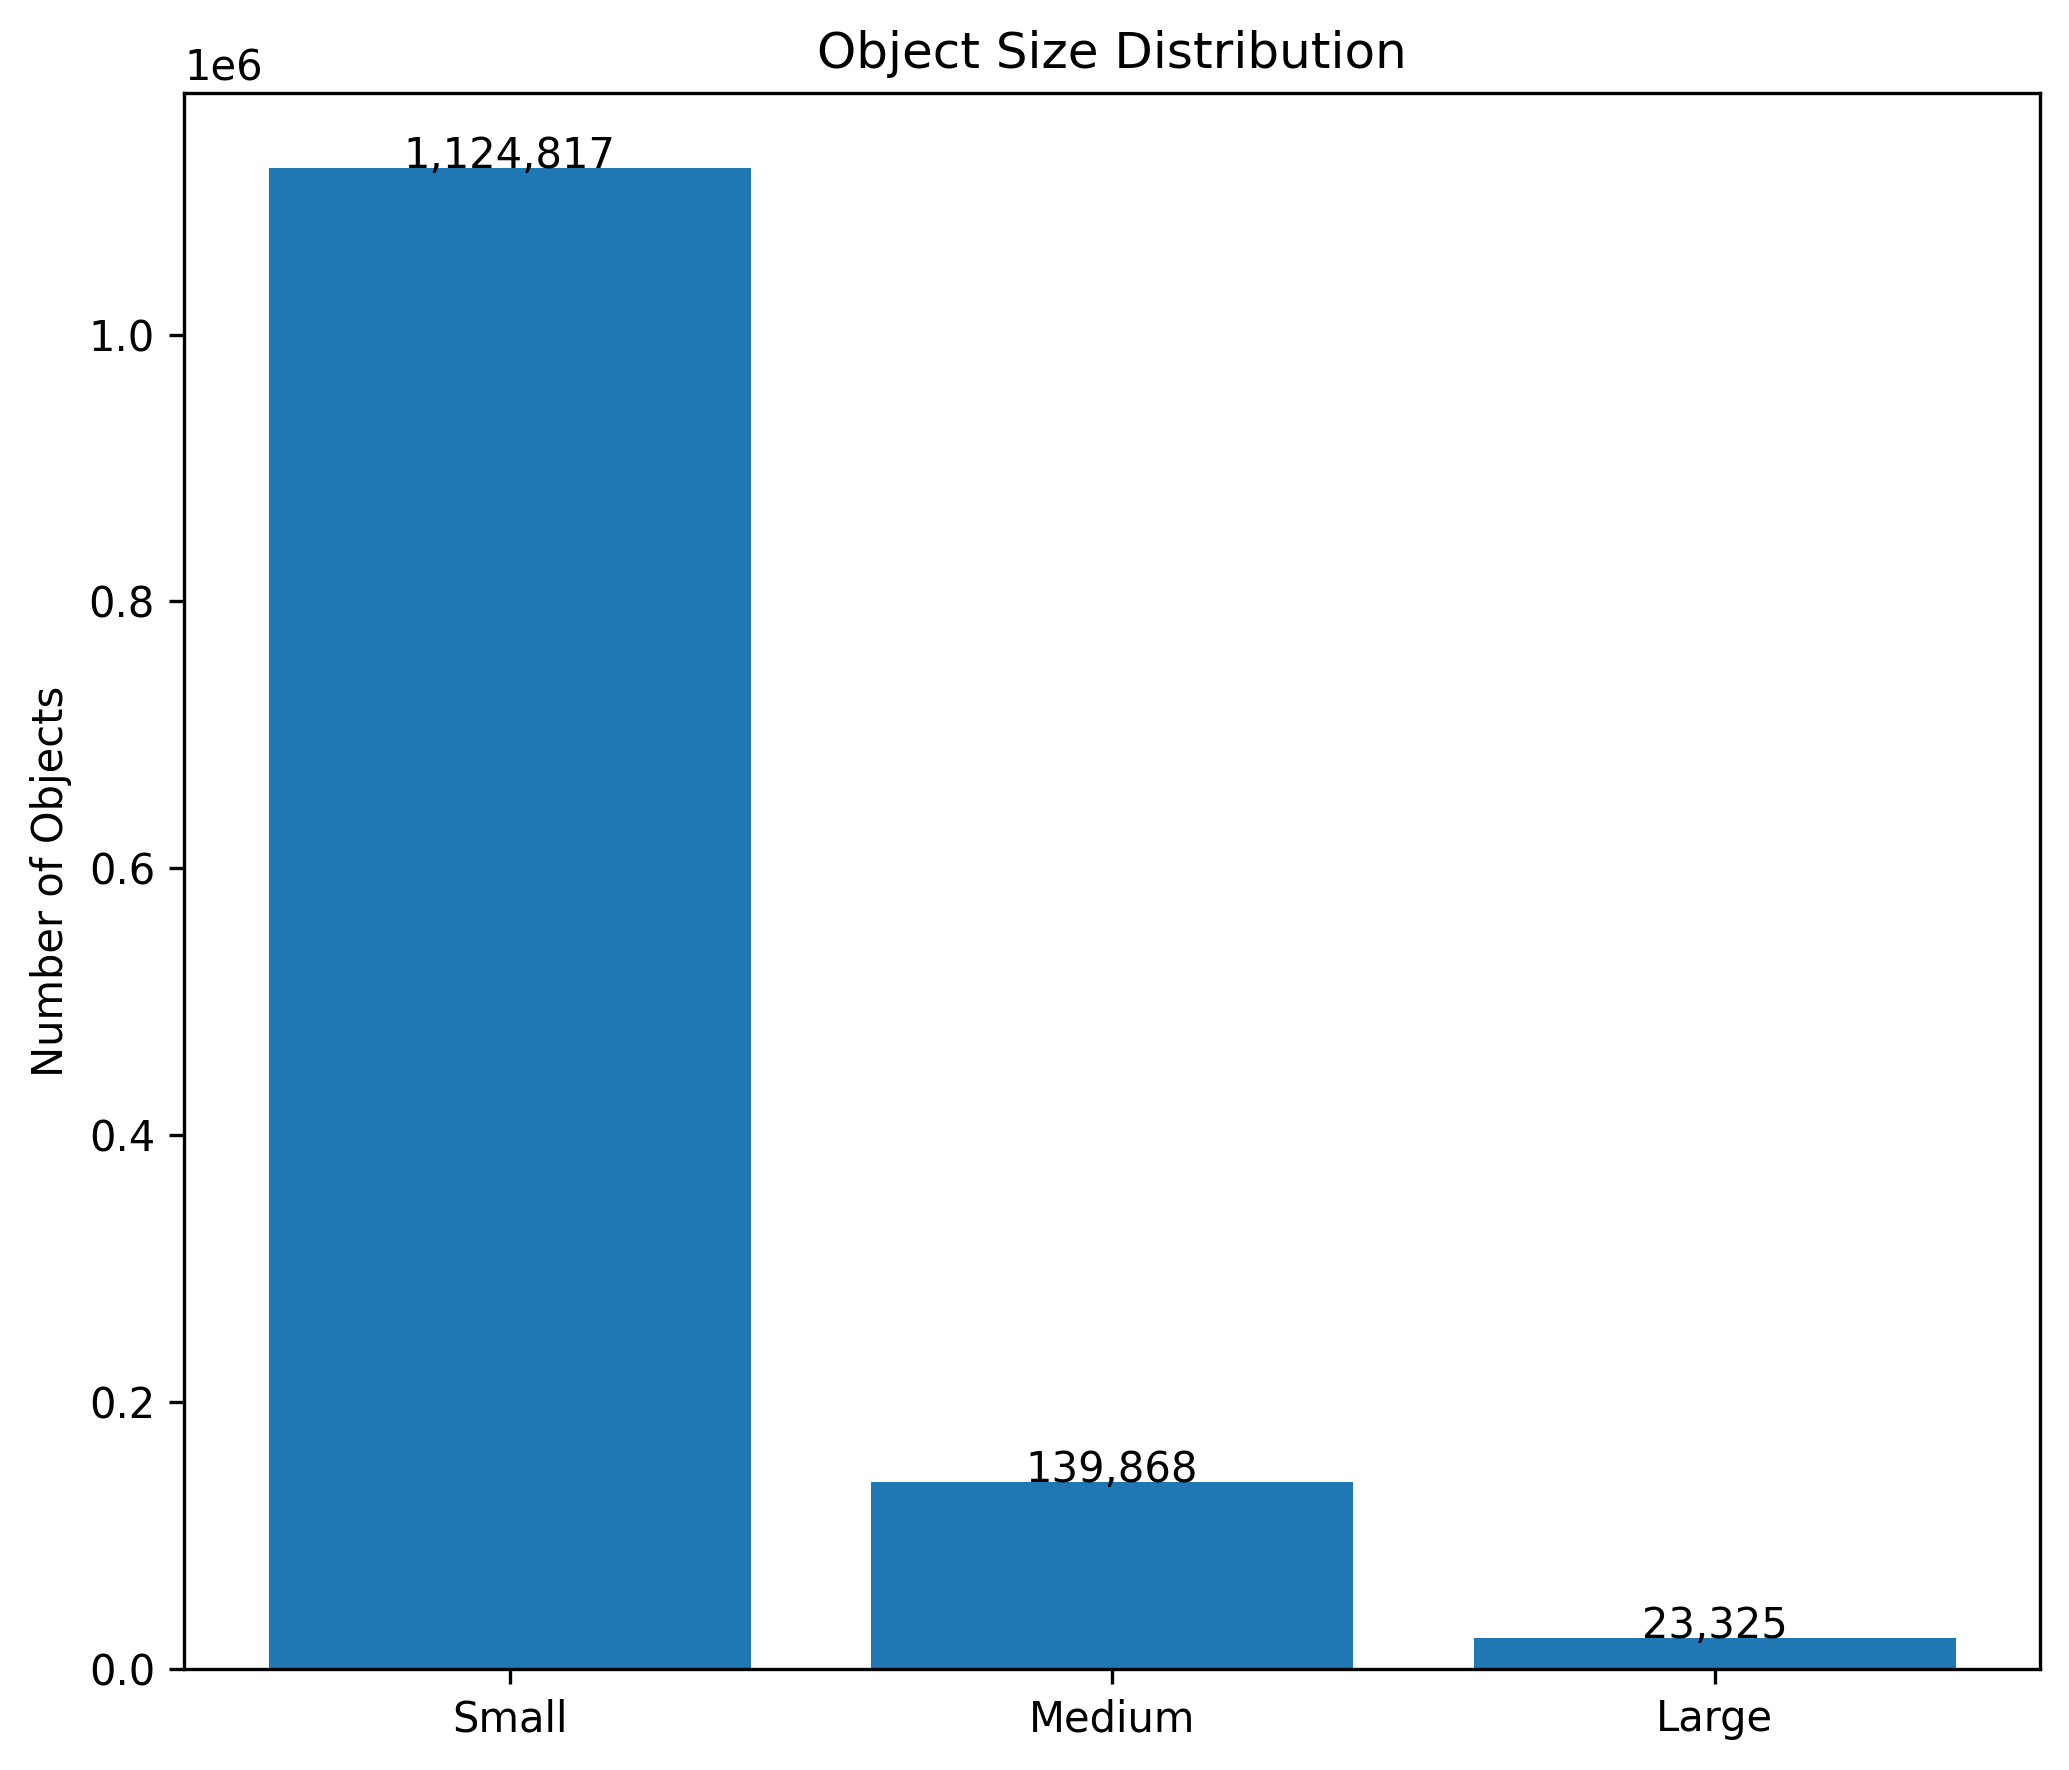

Object Size Statistics
Small  : 1,124,817 (87.33%)
Medium : 139,868 (10.86%)
Large  : 23,325 (1.81%)


In [9]:
small = 0
medium = 0
large = 0

for label_file in train_labels.glob("*.txt"):
    with open(label_file,"r") as f:
        for line in f:
            values = line.strip().split()

            if len(values) != 5:
                continue
            width = float(values[3])
            height = float(values[4])
            area = width * height

            if area < 0.01:
                small += 1
            elif area < 0.09:
                medium += 1
            else:
                large += 1

sizes = [small, medium, large]
labels = ["Small","Medium","Large"]

plt.figure(figsize=(7,6), dpi=300)
bars = plt.bar(labels, sizes)

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():,}",
        ha="center",
        fontsize=10
    )

plt.title("Object Size Distribution")
plt.ylabel("Number of Objects")
plt.tight_layout()
plt.savefig(
    figure_folder / "object_size_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

total = sum(sizes)

print("="*60)
print("Object Size Statistics")
print("="*60)
print(f"Small  : {small:,} ({small/total*100:.2f}%)")
print(f"Medium : {medium:,} ({medium/total*100:.2f}%)")
print(f"Large  : {large:,} ({large/total*100:.2f}%)")

Object Center Heatmap

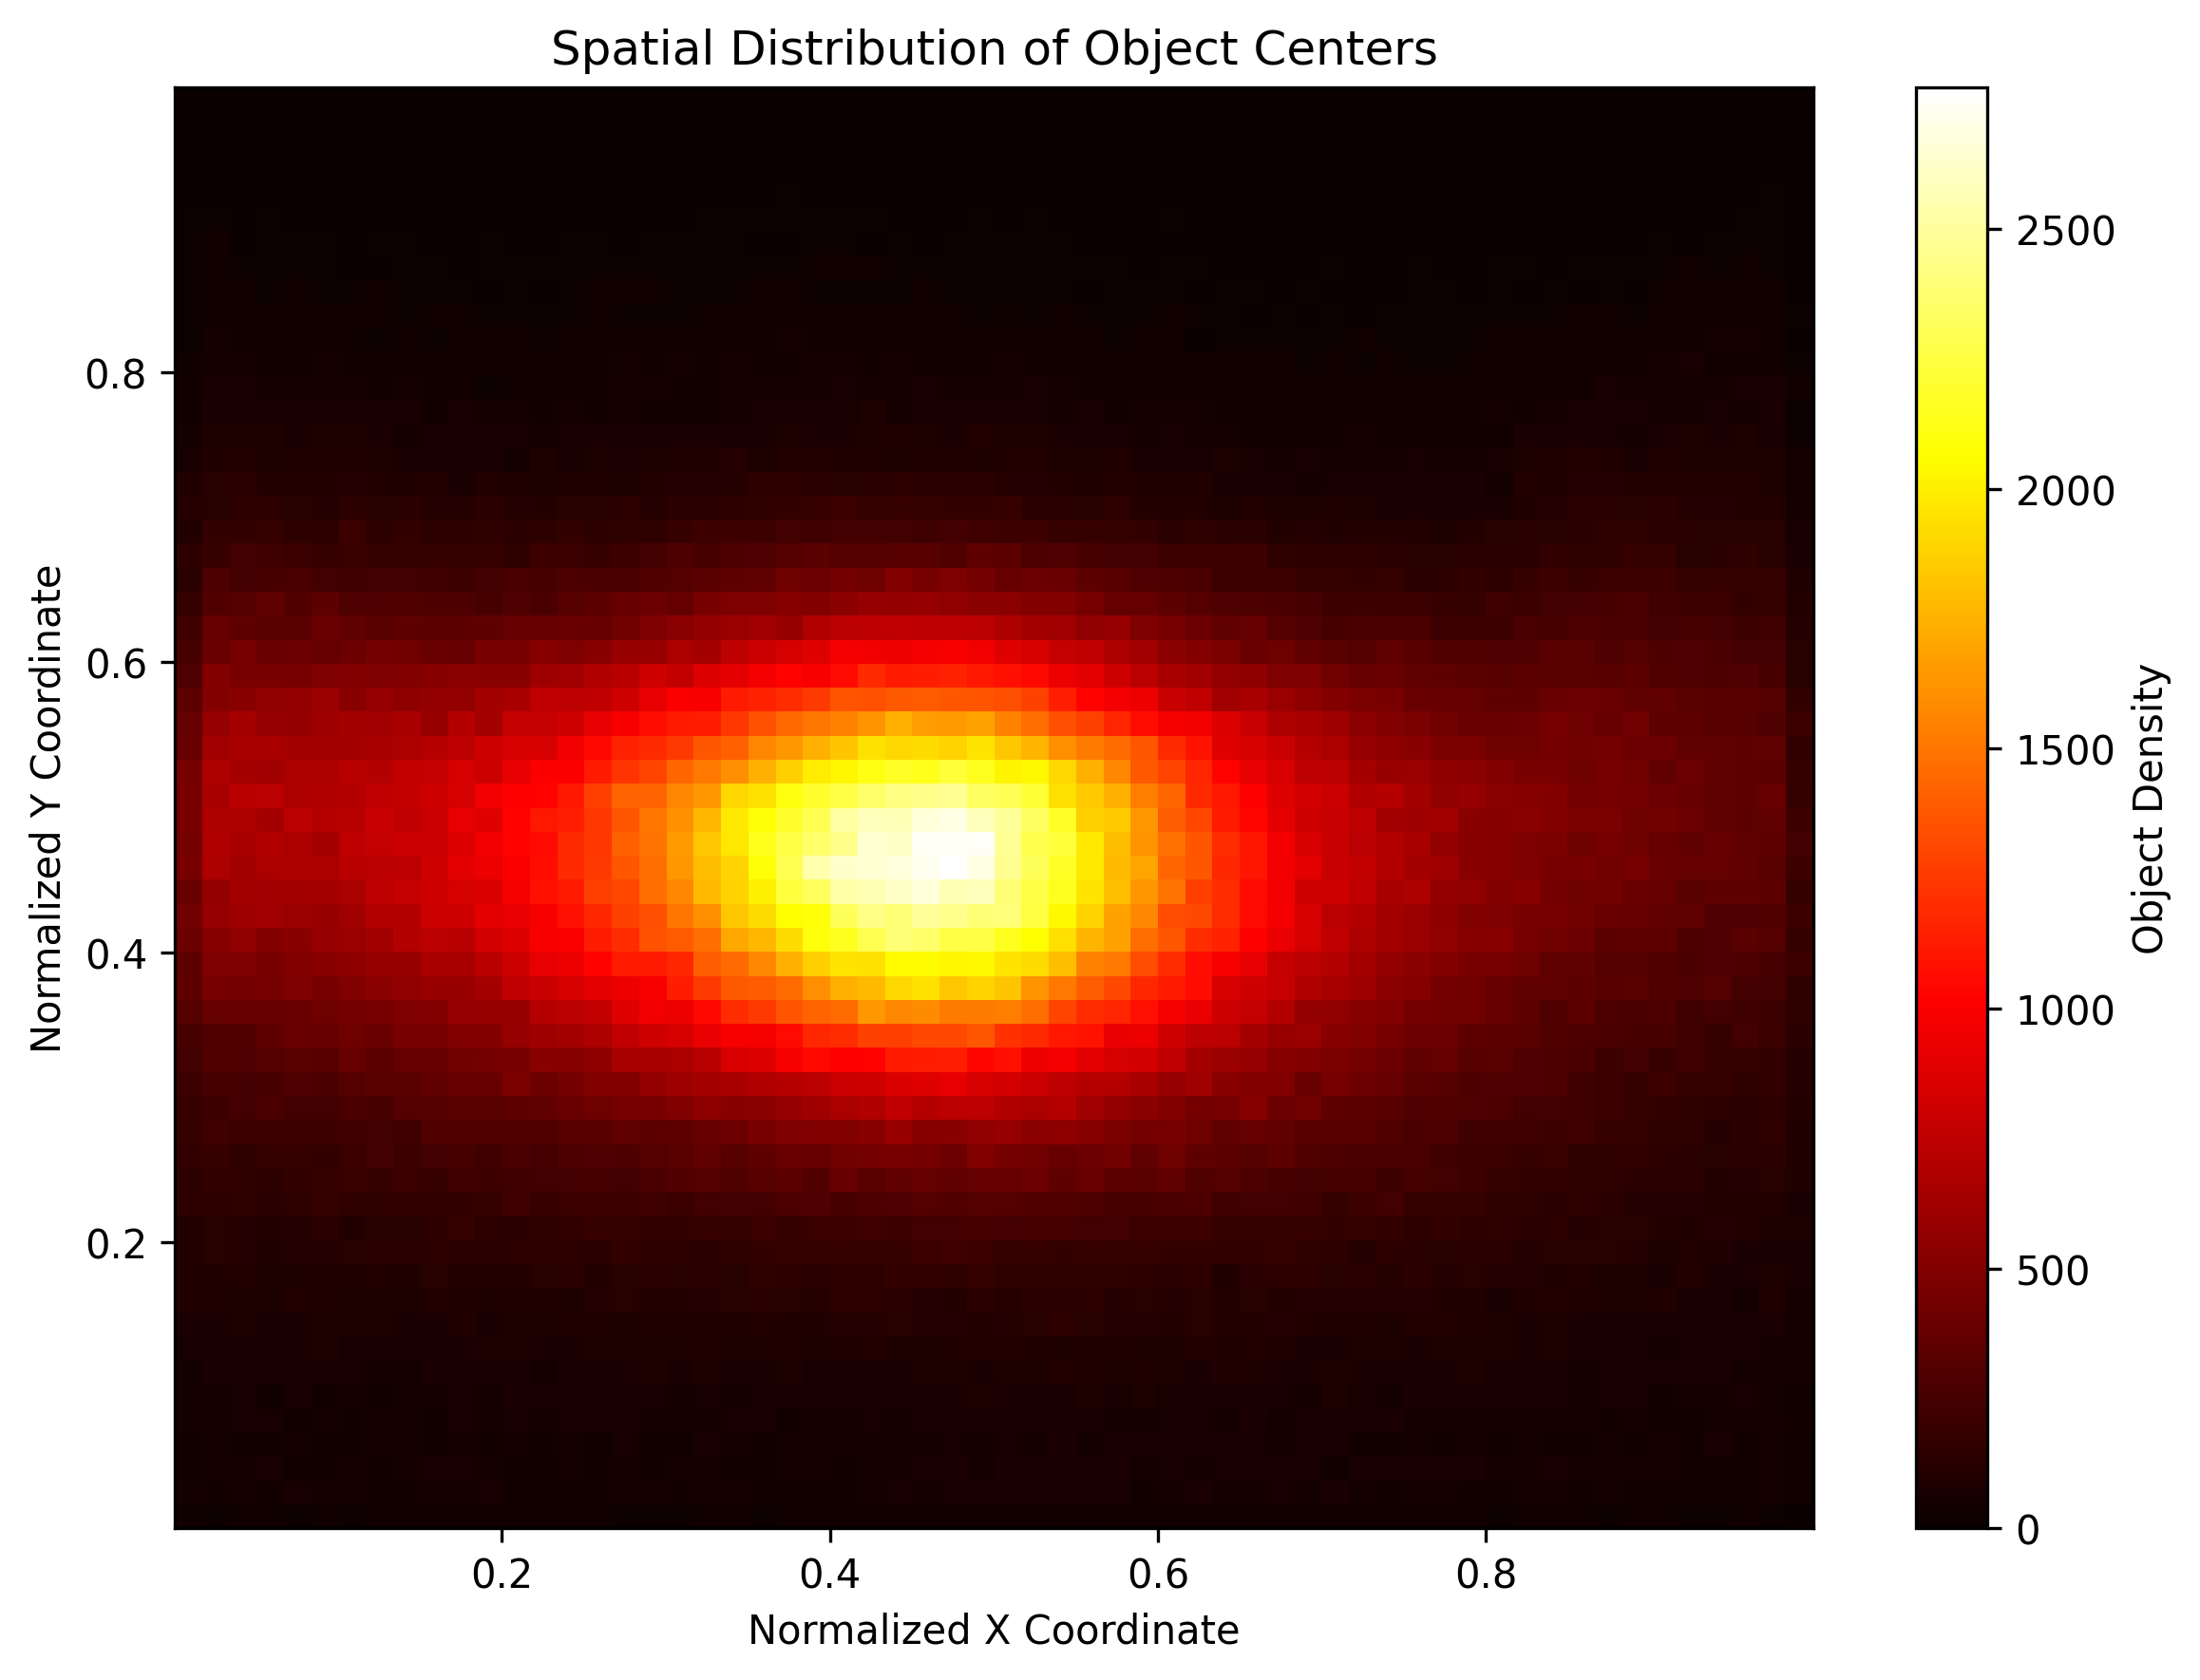

In [10]:
x_centers = []
y_centers = []

for label_file in train_labels.glob("*.txt"):
    with open(label_file,"r") as f:
        for line in f:
            values = line.strip().split()

            if len(values) != 5:
                continue
            x_centers.append(float(values[1]))
            y_centers.append(float(values[2]))

plt.figure(figsize=(8,6), dpi=300)
plt.hist2d(
    x_centers,
    y_centers,
    bins=60,
    cmap="hot"
)
plt.colorbar(label="Object Density")
plt.title("Spatial Distribution of Object Centers")
plt.xlabel("Normalized X Coordinate")
plt.ylabel("Normalized Y Coordinate")
plt.tight_layout()
plt.savefig(
    figure_folder / "object_center_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

EDA Summary

In [11]:
print("="*70)
print("RESEARCH EDA SUMMARY")
print("="*70)

print(f"Training Images        : {train_count:,}")
print(f"Validation Images      : {valid_count:,}")
print(f"Testing Images         : {test_count:,}")

print()

print(f"Image Resolution       : 1280 × 720")
print(f"Average Objects/Image  : {objects_per_image.mean():.2f}")

print()

print("Research Findings")
print("------------------------------")

print("• All images have a uniform resolution.")
print("• The dataset contains complex traffic scenes with multiple objects.")
print("• The dataset is highly imbalanced across object classes.")
print("• Small objects dominate the dataset.")
print("• Object locations are spatially concentrated rather than uniformly distributed.")

print()

print("Implication for Research")
print("------------------------------")

print("These characteristics justify adaptive preprocessing")
print("to improve object detection robustness across")
print("different object scales and complex scenes.")

print()

print("✓ Notebook 2 (EDA) completed successfully.")

RESEARCH EDA SUMMARY
Training Images        : 70,000
Validation Images      : 10,000
Testing Images         : 20,000

Image Resolution       : 1280 × 720
Average Objects/Image  : 18.40

Research Findings
------------------------------
• All images have a uniform resolution.
• The dataset contains complex traffic scenes with multiple objects.
• The dataset is highly imbalanced across object classes.
• Small objects dominate the dataset.
• Object locations are spatially concentrated rather than uniformly distributed.

Implication for Research
------------------------------
These characteristics justify adaptive preprocessing
to improve object detection robustness across
different object scales and complex scenes.

✓ Notebook 2 (EDA) completed successfully.
